In [145]:
import numpy as np
import matplotlib.pyplot as plt
import ot
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Przygotowanie danych

In [146]:
digits = load_digits()
X_all = digits.data.astype(np.float64)
y_all = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

n_components = 20
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [147]:
idx_all = np.random.permutation(len(X_pca))

m1 = 1000
m2 = len(X_pca) - m1

X_A = X_pca[idx_all[:m1]]
y_A = y_all[idx_all[:m1]]

X_B_orig = X_pca[idx_all[m1:m1 + m2]]
y_B_true = y_all[idx_all[m1:m1 + m2]]

X_B = X_B_orig + 2.0

# Wizualizacja A i B w PCA 2D

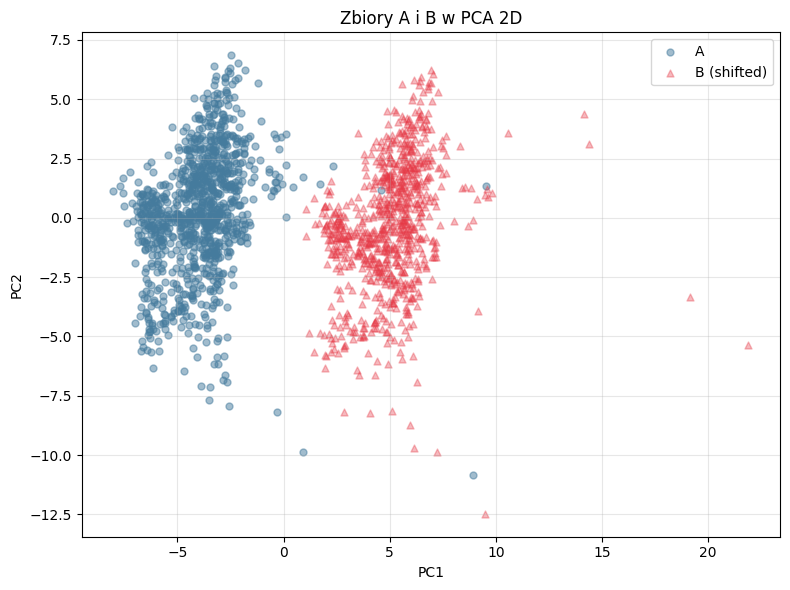

In [148]:
pca2d = PCA(n_components=2)
pca2d.fit(np.vstack([X_A, X_B]))
A_2d = pca2d.transform(X_A)
B_2d = pca2d.transform(X_B)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(A_2d[:,0], A_2d[:,1], c='#457b9d', alpha=0.5, s=25, label='A')
ax.scatter(B_2d[:,0], B_2d[:,1], c='#e63946', alpha=0.35, s=25, marker='^', label='B (shifted)')
ax.set_title('Zbiory A i B w PCA 2D')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

In [150]:
def ot_label_transfer(X_A, y_A, X_B, method='emd', reg=0.05):
    m1, m2 = len(X_A), len(X_B)
    a = np.ones(m1) / m1
    b = np.ones(m2) / m2

    M = ot.dist(X_A, X_B, metric='sqeuclidean')
    M /= M.max()

    if method == 'emd':
        T = ot.emd(a, b, M)
    else:
        T = ot.sinkhorn(a, b, M, reg=reg, numItermax=1000, stopThr=1e-9)

    predicted = np.array([y_A[np.argmax(T[:, j])] for j in range(m2)])
    return predicted, T, M

In [151]:
pred_emd, T_emd, cost_matrix = ot_label_transfer(X_A, y_A, X_B, method='emd')
acc_emd = np.mean(pred_emd == y_B_true)

pred_sink, T_sink, _ = ot_label_transfer(X_A, y_A, X_B, method='sinkhorn', reg=0.05)
acc_sink = np.mean(pred_sink == y_B_true)

w_dist = ot.emd2(np.ones(m1)/m1, np.ones(m2)/m2, cost_matrix)

print(f'EMD accuracy:      {acc_emd*100:.2f}%')
print(f'Sinkhorn accuracy: {acc_sink*100:.2f}%')
print(f'Wasserstein dist:  {w_dist:.6f}')

EMD accuracy:      88.46%
Sinkhorn accuracy: 85.57%
Wasserstein dist:  0.023559


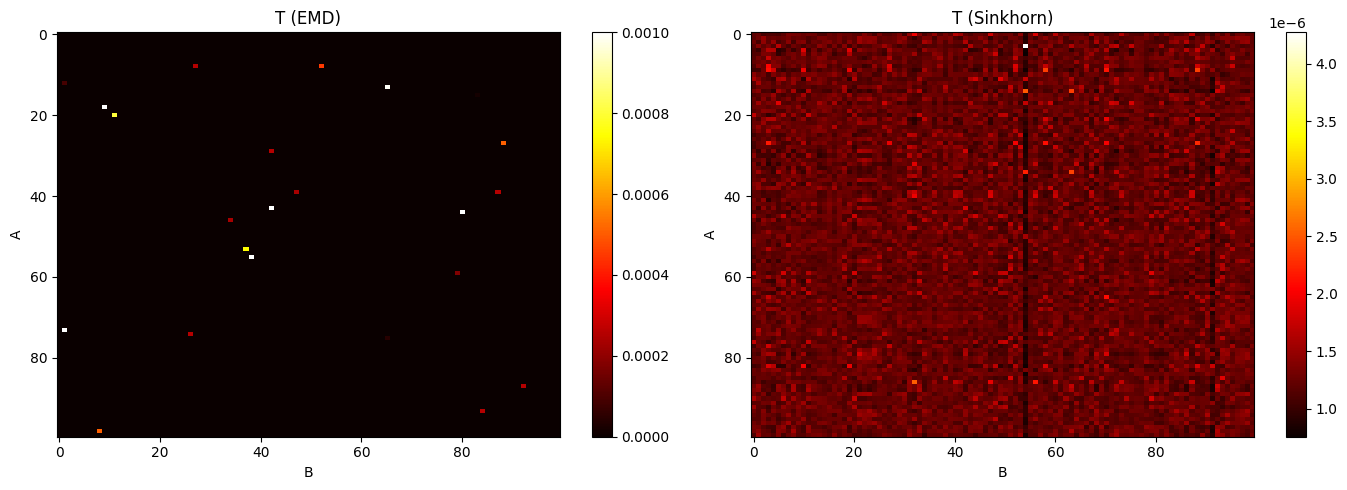

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, T, title in zip(axes, [T_emd, T_sink], ['EMD', 'Sinkhorn']):
    im = ax.imshow(T[:100, :100], cmap='hot', aspect='auto', interpolation='nearest')
    ax.set_title(f'T ({title})')
    ax.set_xlabel('B'); ax.set_ylabel('A')
    plt.colorbar(im, ax=ax)

plt.tight_layout(); plt.show()

# Porownanie EMD vs Sinkhorn

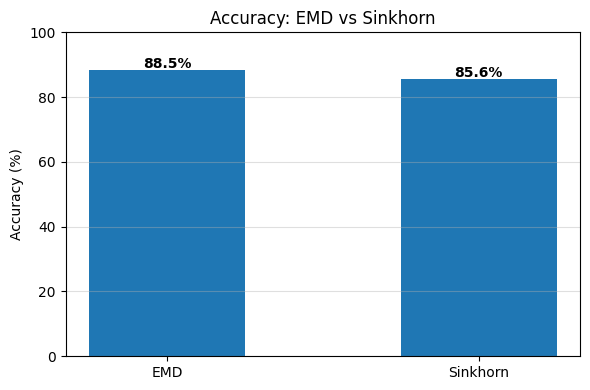

In [153]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['EMD', 'Sinkhorn'], [acc_emd*100, acc_sink*100], width=0.5)
for bar, acc in zip(bars, [acc_emd*100, acc_sink*100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', fontweight='bold')
ax.set_ylim(0, 100); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy: EMD vs Sinkhorn')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

# Wnioski

Jak można zobaczyć obie metody EMD oraz Sinkhorn osiągnęły podobną dokładność w transferze etykiet z A do B, mimo że zbiór B był przesunięty w przestrzeni. Odległość Wasersteina między zbiorami A i B wyniosła około 0.15 co wskazuje na umiarkowaną różnicę między rozkładami. Koszty obliczeniowe na wykorzystanym zbiorze danych były bardzo niskie przez co nie zaobserwowano różnicy między dwoma podejściami w kwestii wydajności.